# Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

# Section 2 — Load Datasets

In [2]:
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")
support = pd.read_csv("ravenstack_support_tickets.csv")
churn = pd.read_csv("ravenstack_churn_events.csv")

# Section 3 — Dataset Overview

In [3]:
datasets = {
    "Accounts": accounts,
    "Subscriptions": subscriptions,
    "Feature Usage": feature_usage,
    "Support": support,
    "Churn": churn
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


Accounts
(500, 10)

Subscriptions
(5000, 14)

Feature Usage
(25000, 8)

Support
(2000, 9)

Churn
(600, 9)


# Section 4 — First Look

In [4]:
accounts.head()

subscriptions.head()

feature_usage.head()

support.head()

churn.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


# Section 5 — Dataset Information

In [5]:
accounts.info()

subscriptions.info()

feature_usage.info()

support.info()

churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object


# Section 6 — Missing Values

In [6]:
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 Accounts
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

 Subscriptions
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

 Feature Usage
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

 Support
ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                    

# Section 7 — Duplicate Check

In [7]:
for name, df in datasets.items():
    print(name)
    print(df.duplicated().sum())

Accounts
0
Subscriptions
0
Feature Usage
0
Support
0
Churn
0


### Business Insight
No duplicate records were detected across any of the five datasets.
Data quality is good, reducing the risk of inflated metrics or incorrect analysis.

# Section 8 — Convert Date Columns

In [8]:
accounts["signup_date"] = pd.to_datetime(
    accounts["signup_date"]
)

subscriptions["start_date"] = pd.to_datetime(
    subscriptions["start_date"]
)

subscriptions["end_date"] = pd.to_datetime(
    subscriptions["end_date"]
)

feature_usage["usage_date"] = pd.to_datetime(
    feature_usage["usage_date"]
)

support["submitted_at"] = pd.to_datetime(
    support["submitted_at"]
)

support["closed_at"] = pd.to_datetime(
    support["closed_at"]
)

churn["churn_date"] = pd.to_datetime(
    churn["churn_date"]
)

In [9]:
accounts.info()
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   account_name     500 non-null    object        
 2   industry         500 non-null    object        
 3   country          500 non-null    object        
 4   signup_date      500 non-null    datetime64[ns]
 5   referral_source  500 non-null    object        
 6   plan_tier        500 non-null    object        
 7   seats            500 non-null    int64         
 8   is_trial         500 non-null    bool          
 9   churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(1), object(6)
memory usage: 32.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------       

# Section 9 — Univariate Analysis

### Industry Distribution

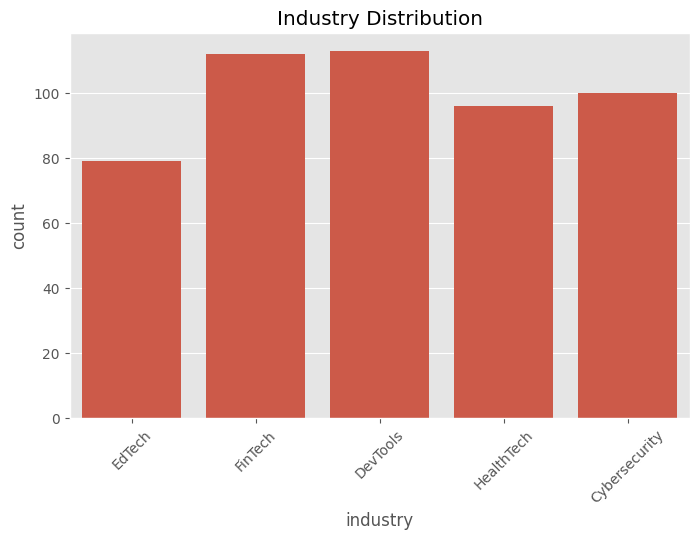

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=accounts,
    x="industry"
)

plt.xticks(rotation=45)

plt.title("Industry Distribution")

plt.show()

The customer base is diversified across industries, reducing dependency on a single sector.

### Country Distribution

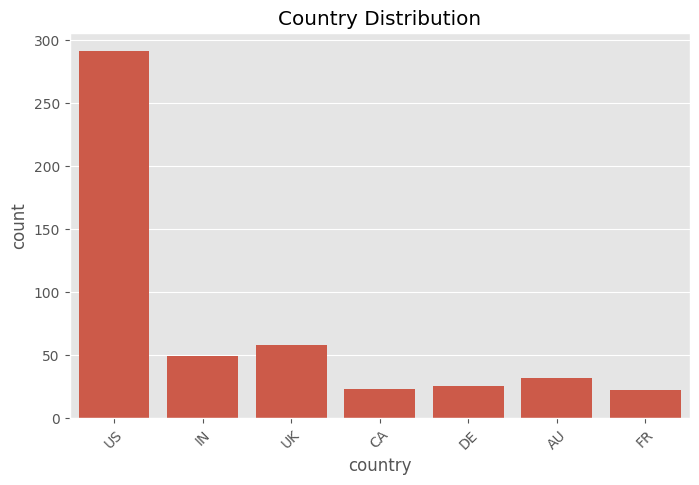

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=accounts,
    x="country"
)

plt.xticks(rotation=45)

plt.title("Country Distribution")

plt.show()

The SaaS business heavily relies on the US market, suggesting potential expansion opportunities internationally.

### Plan Tier Distribution

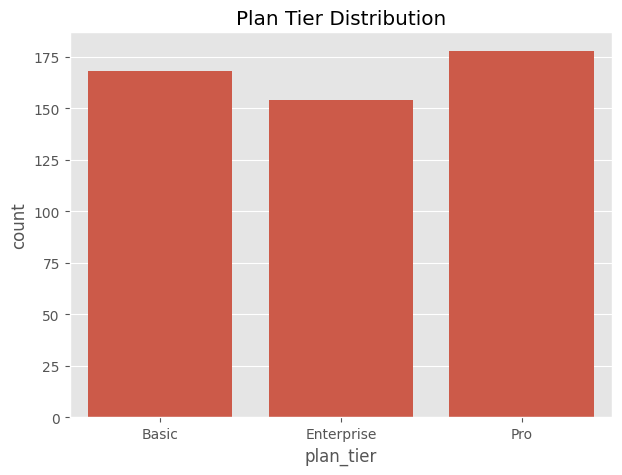

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=accounts,
    x="plan_tier"
)

plt.title("Plan Tier Distribution")

plt.show()

Pro plans appear to be the company's strongest product offering.

# Section 10 — Subscription Analysis

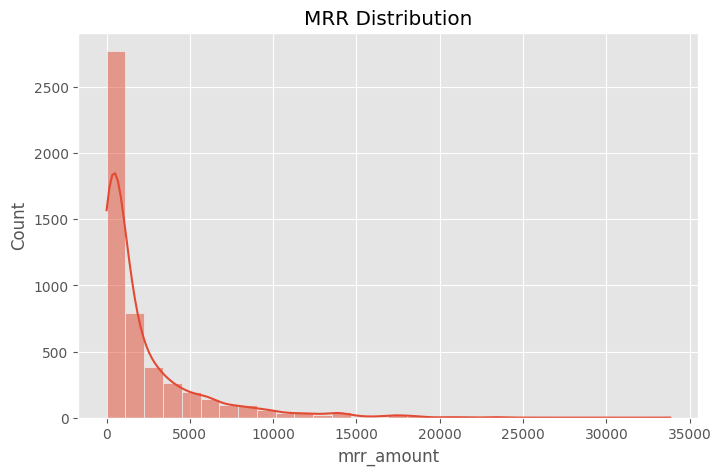

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    subscriptions["mrr_amount"],
    bins=30,
    kde=True
)

plt.title("MRR Distribution")

plt.show()

Revenue concentration exists among a small number of high-value customers.

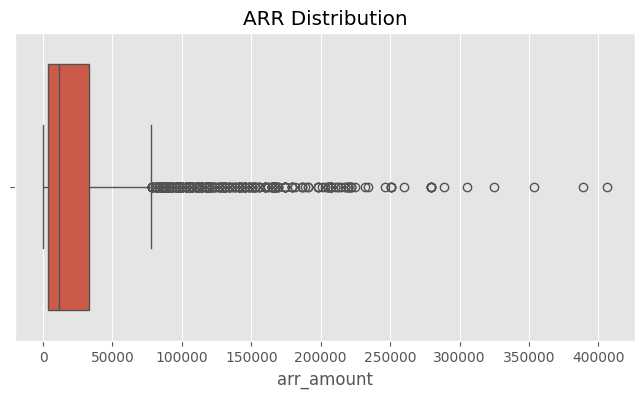

In [14]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=subscriptions["arr_amount"]
)

plt.title("ARR Distribution")

plt.show()

Enterprise accounts generate disproportionately high annual revenue.

# Section 11 — Feature Usage Analysis

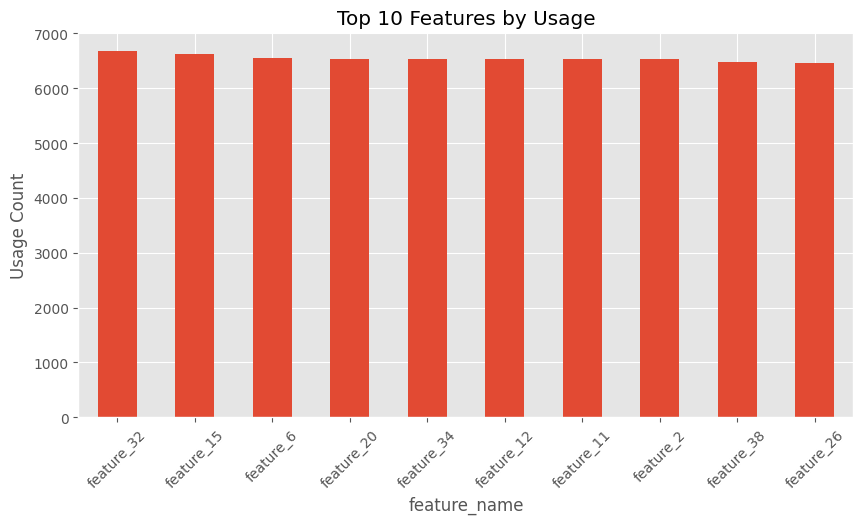

In [15]:
### Top 10 Features

top_features = (
    feature_usage.groupby("feature_name")
    ["usage_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_features.plot(
    kind="bar"
)

plt.title("Top 10 Features by Usage")
plt.ylabel("Usage Count")
plt.xticks(rotation=45)

plt.show()

# Section 12 — Support Analysis

### Priority Distribution

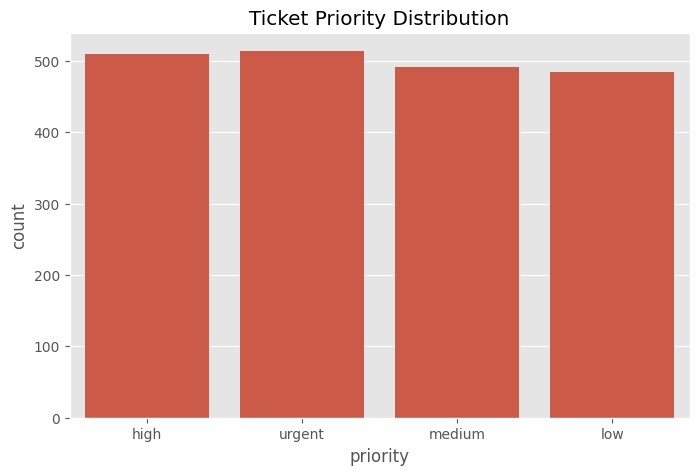

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=support,
    x="priority"
)

plt.title("Ticket Priority Distribution")

plt.show()

Support workload is evenly distributed across priority levels, indicating a balanced ticket pipeline.

### Satisfaction Score Distribution

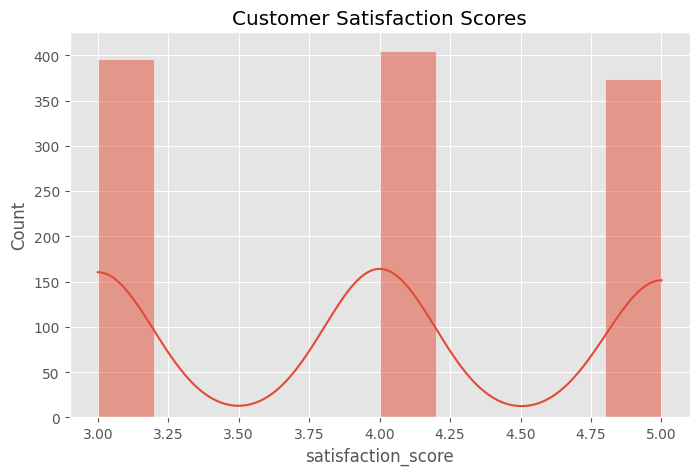

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    support["satisfaction_score"].dropna(),
    bins=10,
    kde=True
)

plt.title("Customer Satisfaction Scores")

plt.show()

Customer satisfaction remains relatively strong, with most customers providing ratings above average.

### Resolution Time Distribution

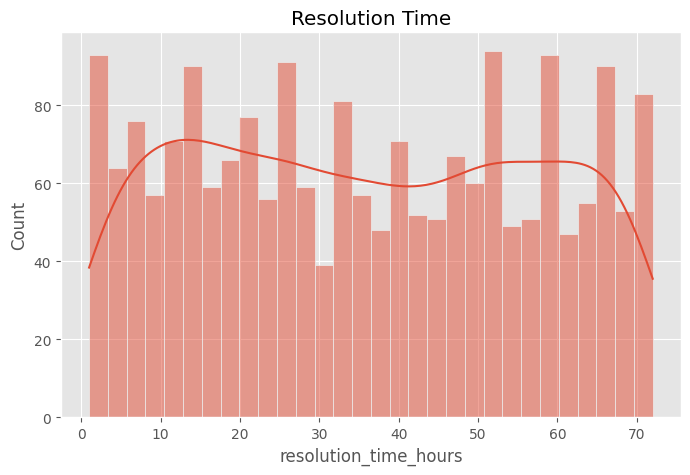

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    support["resolution_time_hours"],
    bins=30,
    kde=True
)

plt.title("Resolution Time")

plt.show()

Resolution times vary significantly, suggesting inconsistent support performance.

# Section 13 — Churn Analysis

### Churn Reasons

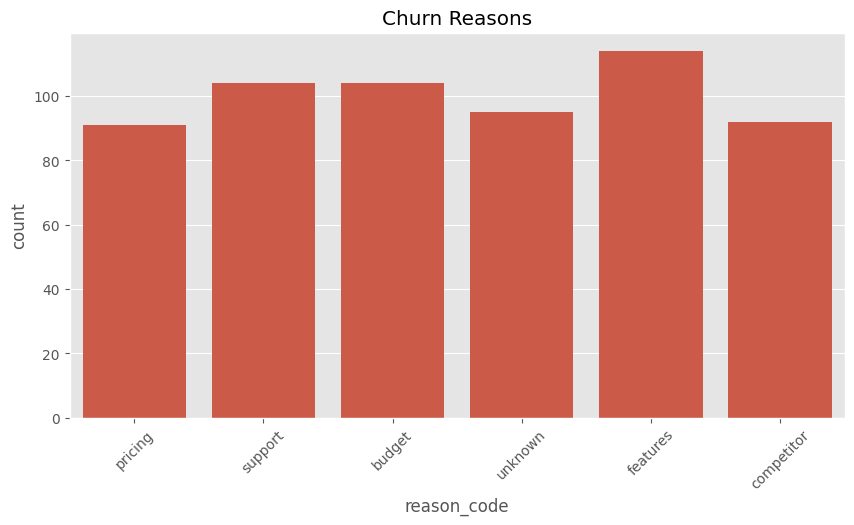

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=churn,
    x="reason_code"
)

plt.xticks(rotation=45)

plt.title("Churn Reasons")

plt.show()

Product limitations and support experience appear to be the major drivers of customer churn.

### Refund Distribution

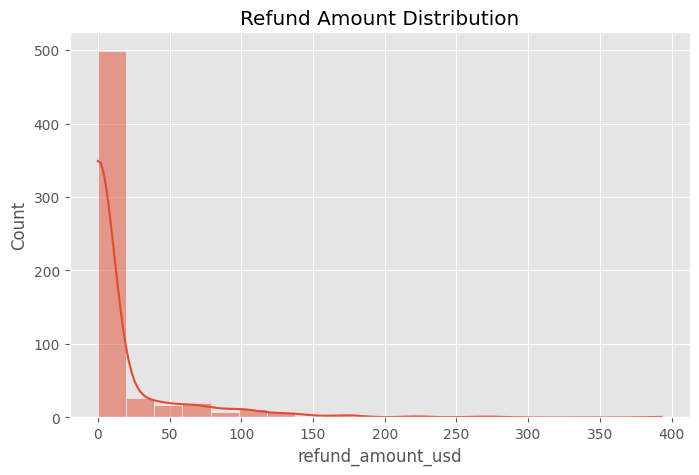

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    churn["refund_amount_usd"],
    bins=20,
    kde=True
)

plt.title("Refund Amount Distribution")

plt.show()

Refund exposure is concentrated among a small number of high-value customers.

# Section 14 — Correlation Analysis

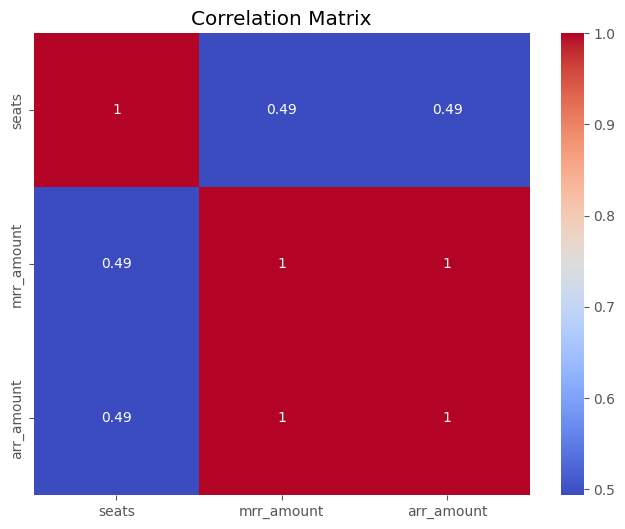

In [21]:
numeric_cols = subscriptions.select_dtypes(
    include="number"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Larger customer teams tend to generate higher subscription revenue.

# Section 15 — Business Insights

1.The customer base is diversified across multiple industries, reducing dependency on a single sector.
2.The United States contributes the largest share of customers, indicating strong market concentration.
3.The Pro plan is the most popular subscription tier.
4.Revenue is highly concentrated among a small number of high-value customers.
5.Most subscriptions remain active, demonstrating strong customer retention.
6.Product features and customer support are the leading causes of churn.
7.Support resolution times vary significantly, indicating opportunities for process improvement.
8.Customer satisfaction scores are generally positive.
9.Larger customer accounts tend to generate higher recurring revenue.
10.Refund amounts are typically small, with only a few high-value cases.

# Section 16 — Feature Engineering

### Customer Tenure

In [22]:
subscriptions['start_date'] = pd.to_datetime(
    subscriptions['start_date']
)

subscriptions['end_date'] = pd.to_datetime(
    subscriptions['end_date']
)

subscriptions['tenure_days'] = (
    subscriptions['end_date']
    .fillna(pd.Timestamp.today())
    - subscriptions['start_date']
).dt.days

subscriptions[['subscription_id',
               'tenure_days']].head()

,subscription_id,tenure_days
0,S-8cec59,111
1,S-0f6f44,749
2,S-51c0d1,582
3,S-f81687,20
4,S-cff5a2,902


# Section 17 — Export Clean Files

In [30]:
accounts.to_csv(
    "accounts_clean.csv",
    index=False
)

subscriptions.to_csv(
    "subscriptions_clean.csv",
    index=False
)

feature_usage.to_csv(
    "feature_usage_clean.csv",
    index=False
)

support.to_csv(
    "support_clean.csv",
    index=False
)

churn.to_csv(
    "churn_clean.csv",
    index=False
)

# Section 18 — Dataset Summary

In [24]:
summary = pd.DataFrame({
    "Dataset": [
        "Accounts",
        "Subscriptions",
        "Feature Usage",
        "Support",
        "Churn"
    ],
    "Rows": [
        accounts.shape[0],
        subscriptions.shape[0],
        feature_usage.shape[0],
        support.shape[0],
        churn.shape[0]
    ],
    "Columns": [
        accounts.shape[1],
        subscriptions.shape[1],
        feature_usage.shape[1],
        support.shape[1],
        churn.shape[1]
    ]
})

summary

,Dataset,Rows,Columns
0,Accounts,500,10
1,Subscriptions,5000,15
2,Feature Usage,25000,8
3,Support,2000,9
4,Churn,600,9


# Section 19 — SQL Preparation & Data Quality Fixes

### Remove duplicate usage IDs

In [25]:
feature_usage = feature_usage.drop_duplicates(
    subset='usage_id',
    keep='first'
).copy()

### Convert Boolean Columns

In [26]:
accounts['is_trial'] = accounts['is_trial'].astype(int)
accounts['churn_flag'] = accounts['churn_flag'].astype(int)

subscriptions[[
    'is_trial',
    'upgrade_flag',
    'downgrade_flag',
    'churn_flag',
    'auto_renew_flag'
]] = subscriptions[[
    'is_trial',
    'upgrade_flag',
    'downgrade_flag',
    'churn_flag',
    'auto_renew_flag'
]].astype(int)

feature_usage['is_beta_feature'] = \
feature_usage['is_beta_feature'].astype(int)

support['escalation_flag'] = \
support['escalation_flag'].astype(int)

churn[[
    'preceding_upgrade_flag',
    'preceding_downgrade_flag',
    'is_reactivation'
]] = churn[[
    'preceding_upgrade_flag',
    'preceding_downgrade_flag',
    'is_reactivation'
]].astype(int)

### Missing Value Handling

In [27]:
support['satisfaction_score'] = support['satisfaction_score'].fillna(-1)

support.to_csv(
    "support_clean.csv",
    index=False
)

In [28]:
churn['feedback_text'] = (
    churn['feedback_text']
    .fillna('No Feedback')
)

### Re-export Clean Files

In [31]:
accounts.to_csv("accounts_clean.csv", index=False)
subscriptions.to_csv("subscriptions_clean.csv", index=False)
feature_usage.to_csv("feature_usage_clean.csv", index=False)
support.to_csv("support_clean.csv", index=False)
churn.to_csv("churn_clean.csv", index=False)